# Initial Analysis

In [ ]:
%config InlineBackend.figure_format = 'retina'

from pathlib import Path
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import time

os.environ["PYDEVD_DISABLE_FILE_VALIDATION"] = "1"

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src import load_image, population, rendering
from src.ga import GeneticAlgorithm, fitness, mutate, cross_over


In [14]:
individual = population.create_random_individual()
individual[:5]

[Triangle(x1=14, y1=221, x2=276, y2=307, x3=263, y3=180, r=5, g=8, b=169, a=246),
 Triangle(x1=256, y1=240, x2=101, y2=211, x3=123, y3=260, r=150, g=253, b=118, a=99),
 Triangle(x1=39, y1=396, x2=41, y2=85, x3=234, y3=88, r=99, g=36, b=148, a=101),
 Triangle(x1=99, y1=2, x2=287, y2=394, x3=279, y3=256, r=38, g=12, b=100, a=100),
 Triangle(x1=36, y1=310, x2=85, y2=88, x3=125, y3=335, r=150, g=147, b=50, a=160)]

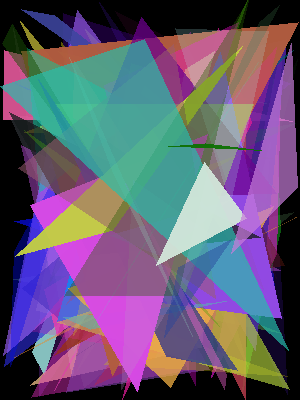

In [15]:
random_image = rendering.render_individual(individual=individual)
random_image

This random initialization confirms that the representation and rendering pipeline are functioning correctly.


In [16]:
# --- Import original paiting image --- #
image_path = os.path.join(project_root, "images/girl_pearl_earing.png")
target_array = load_image.load_target_image(image_path)
print(f"{target_array.shape} -> (H, W, 3) array with RGB values in [0, 255]")

(400, 300, 3) -> (H, W, 3) array with RGB values in [0, 255]


In [17]:
# --- Convert random first image to matrix and compute RMSE --- #
first_target_array = rendering.image_to_array(random_image)
fitness.compute_rmse(target=target_array, generated=first_target_array)

0.32877475023269653

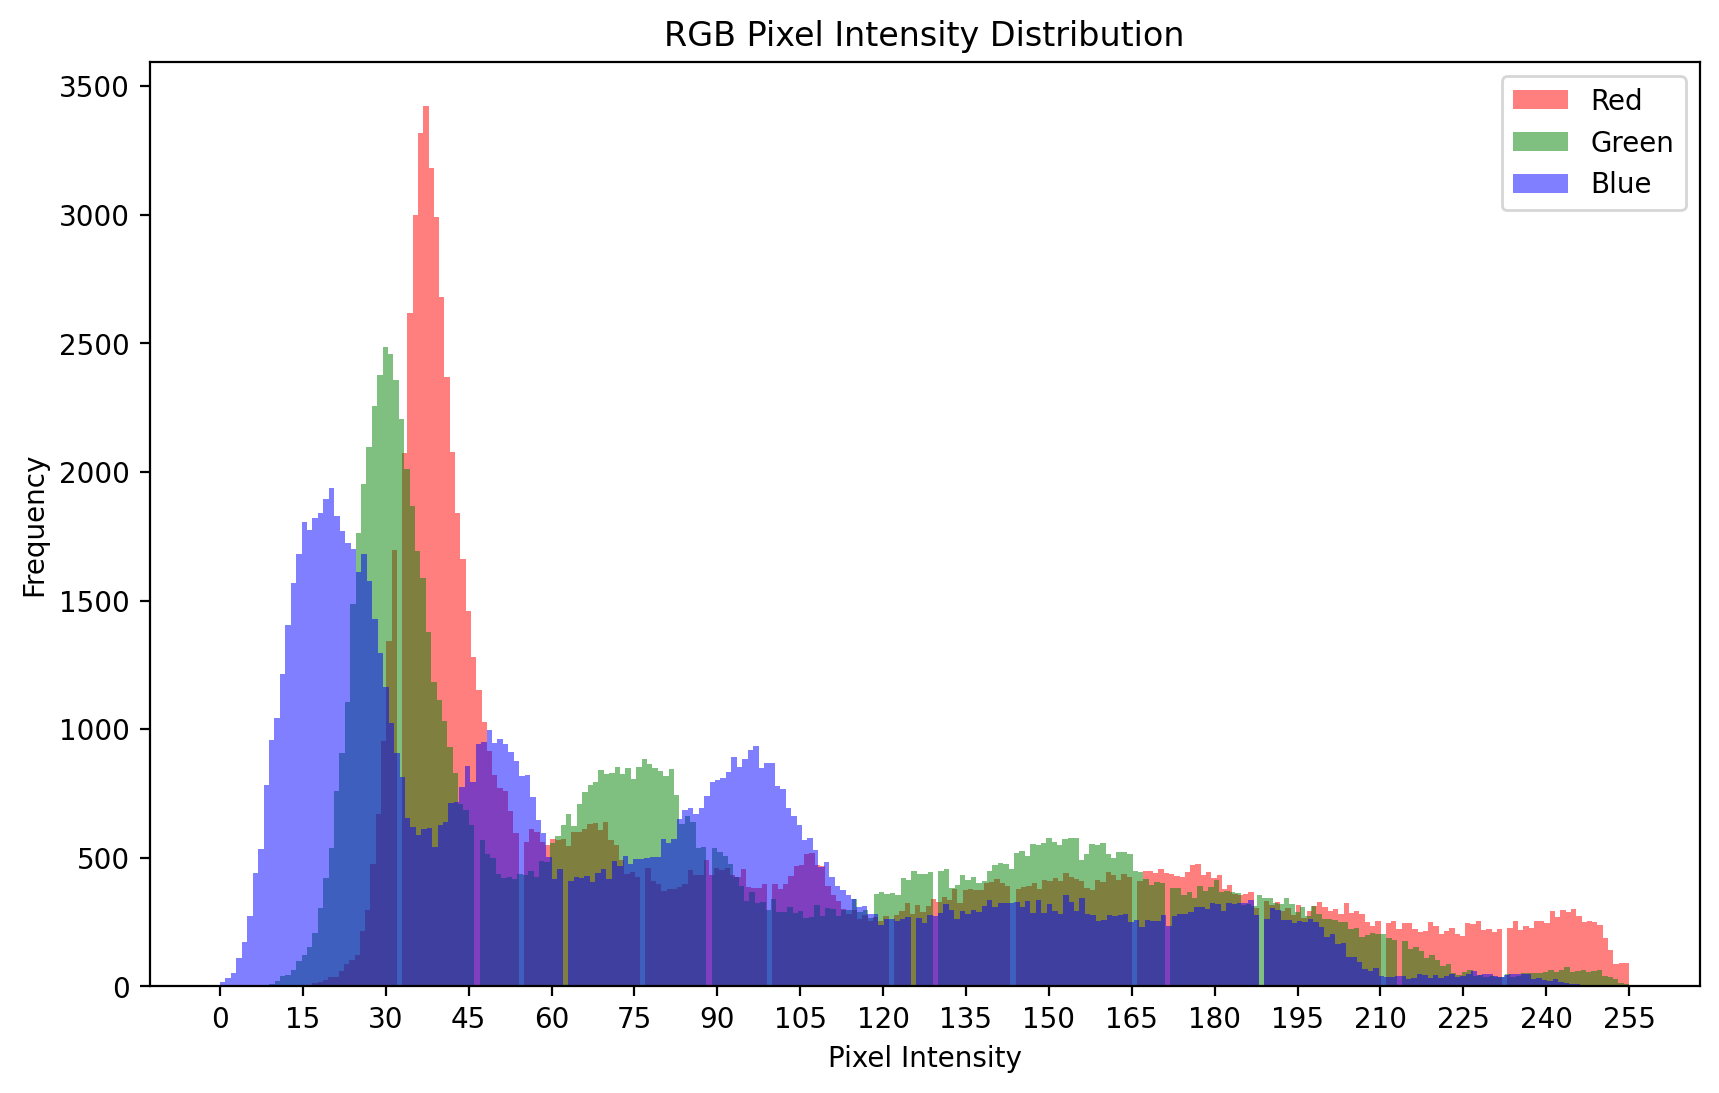

In [18]:
# Separate channels
r = target_array[:, :, 0].flatten()
g = target_array[:, :, 1].flatten()
b = target_array[:, :, 2].flatten()

# Plot histograms
plt.figure(figsize=(10, 6))
plt.hist(r, bins=256, color="red", alpha=0.5, label="Red")
plt.hist(g, bins=256, color="green", alpha=0.5, label="Green")
plt.hist(b, bins=256, color="blue", alpha=0.5, label="Blue")

plt.xticks(np.arange(0, 256, 15))  # ticks every 25
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.title("RGB Pixel Intensity Distribution")
plt.legend()
plt.show()